# **Scenario 2: PCA (Dimensionality Reduction)**
## **Roll No:** 24BAD102
## **Name:** SaiSanjay R

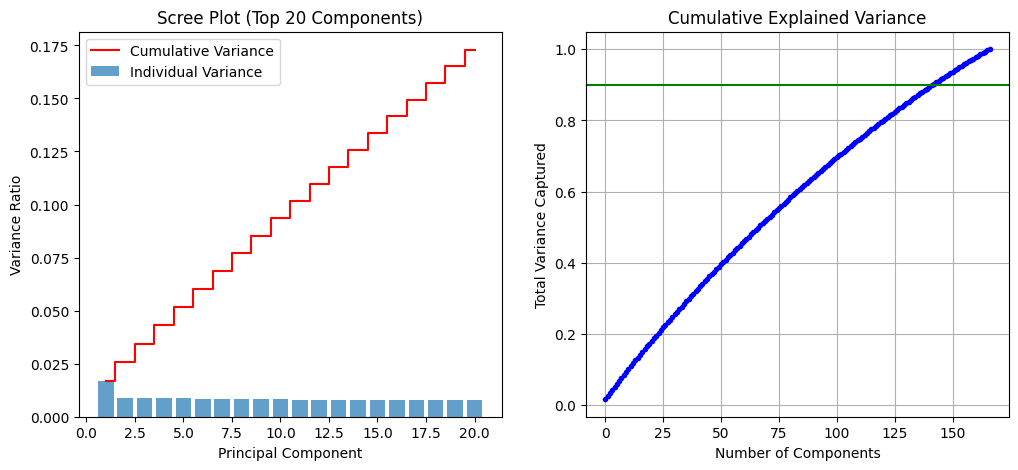

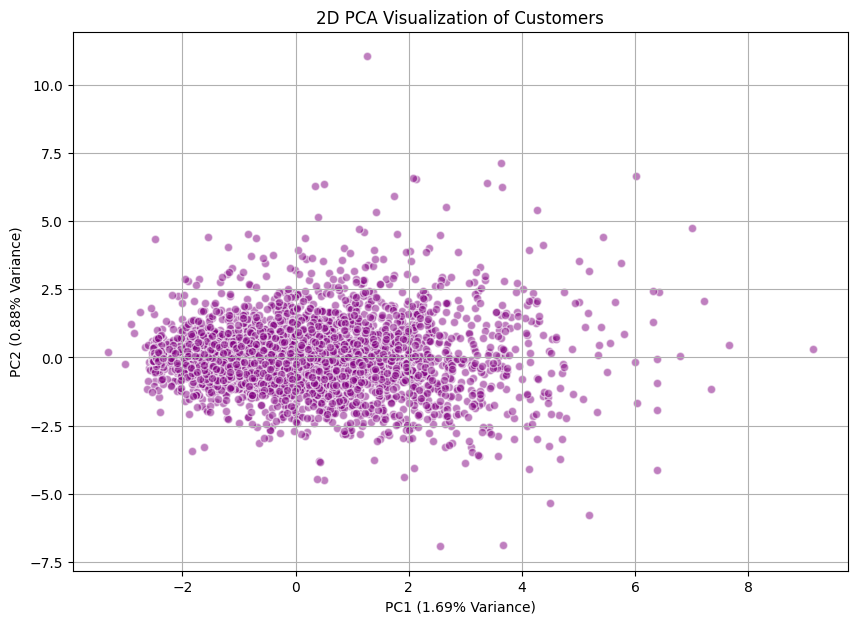

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv('Groceries_dataset.csv')

# 2. Data Preprocessing (Transformation)
# Create a pivot table: Rows = Members, Columns = Items, Values = Count of purchases
basket = df.groupby(['Member_number', 'itemDescription']).size().unstack(fill_value=0)

# 3. Standardize features
# Standardizing is crucial for PCA so that high-frequency items don't dominate components
scaler = StandardScaler()
basket_std = scaler.fit_transform(basket)

# 4. Apply PCA
# We first fit without a limit to analyze the variance
pca = PCA()
pca_transformed = pca.fit_transform(basket_std)

# 6. Determine explained variance ratio
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# --- VISUALIZATIONS ---

# Task: Scree plot and Cumulative variance graph
plt.figure(figsize=(12, 5))

# Plot 1: Scree Plot (Top 20 components)
plt.subplot(1, 2, 1)
plt.bar(range(1, 21), exp_var[:20], alpha=0.7, label='Individual Variance')
plt.step(range(1, 21), cum_var[:20], where='mid', label='Cumulative Variance', color='red')
plt.title('Scree Plot (Top 20 Components)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.legend()

# Plot 2: Cumulative Variance (Full)
plt.subplot(1, 2, 2)
plt.plot(cum_var, marker='.', linestyle='--', color='blue')
plt.axhline(y=0.9, color='green', linestyle='-') # 90% variance line
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Total Variance Captured')
plt.grid(True)
plt.show()

# Task: 2D Scatter plot of principal components
pca_2d = PCA(n_components=2)
components = pca_2d.fit_transform(basket_std)

plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], alpha=0.5, c='purple', edgecolors='w')
plt.title('2D PCA Visualization of Customers')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} Variance)')
plt.grid(True)
plt.show()